### The second choice task
Edit the numbers marked `👈` and re-run.

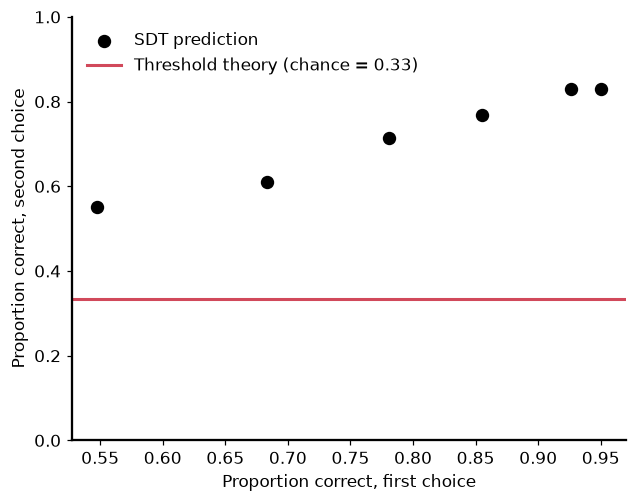

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"
SIGNAL = "#d1495b"
CRIT   = "#333333"

ntrials   = 2000
n_alt     = 4                       # 👈 number of intervals (4AFC); chance = 1/(n_alt-1)
nsignals  = 6
signal_strength = np.linspace(1, 3, nsignals)   # 👈 range of signal strengths to try

rng = np.random.default_rng()
pc_first  = np.full(nsignals, np.nan)
pc_second = np.full(nsignals, np.nan)

for si, s in enumerate(signal_strength):
    evidence = rng.standard_normal((ntrials, n_alt))
    evidence[:, 0] += s                       # put the signal in interval 0
    response1 = np.argmax(evidence, axis=1)

    ev2 = evidence.copy()                      # blank out the first choice, take the next best
    ev2[np.arange(ntrials), response1] = -np.inf
    response2 = np.argmax(ev2, axis=1)

    pc_first[si]  = np.mean(response1 == 0)
    wrong = response1 != 0                      # second choice scored only on incorrect trials
    pc_second[si] = np.mean(response2[wrong] == 0)

chance = 1 / (n_alt - 1)
plt.figure(figsize=(6.5, 5))
plt.scatter(pc_first, pc_second, 60, color="k", zorder=3, label="SDT prediction")
plt.axhline(chance, color=SIGNAL, lw=2, label=f"Threshold theory (chance = {chance:.2f})")
plt.xlabel("Proportion correct, first choice")
plt.ylabel("Proportion correct, second choice")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.show()
